## Cell 1: Install Dependencies


In [1]:
!pip install timm pycocotools torchmetrics scikit-learn matplotlib seaborn pyyaml tqdm -q
import torch
print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"PyTorch: {torch.__version__}")


GPU: Tesla T4
VRAM: 15.6 GB
PyTorch: 2.10.0+cu128


## Cell 2: Clone Repository (source code + trained models)


In [2]:
import os, sys
from pathlib import Path

REPO_URL = 'https://github.com/Thinh59/ECAAL.git'
REPO_DIR = Path('/kaggle/working/ECAAL')

if REPO_DIR.exists():
    print('Repo exists — pulling latest...')
    os.system(f'git -C {REPO_DIR} pull')
else:
    print(f'Cloning {REPO_URL} ...')
    ret = os.system(f'git clone {REPO_URL} {REPO_DIR}')
    if ret != 0:
        raise RuntimeError('git clone failed!')

sys.path.insert(0, str(REPO_DIR / 'src'))
print('Repository OK!')


Cloning https://github.com/Thinh59/ECAAL.git ...


Cloning into '/kaggle/working/ECAAL'...


Repository OK!


## Cell 3: Setup — Copy Trained Models to Working Dir


In [3]:
import shutil, json
from pathlib import Path

OUTPUTS_DIR = Path('/kaggle/working/outputs')
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

# Giữ nguyên đường dẫn root
DATASET_ROOT = Path('/kaggle/input/datasets/thinhha59/models') 
RESULTS_DIR  = DATASET_ROOT / 'results'

# SỬA Ở ĐÂY: Thêm RESULTS_DIR vào trước
SRC_SUBSET   = RESULTS_DIR / 'data' / 'coco_subset' 

EXPS = [
    'exp_A_resnet_bce',
    'exp_B_resnet_asl',
    'exp_C_efficientnet_cbam_asl',
    'exp_D_resnet_focal',
    'exp_E_resnet_cbam_asl',
    'exp_F_efficientnet_asl',
    'exp_G',
]

print(f"Checking models in: {RESULTS_DIR}")
for exp in EXPS:
    src = RESULTS_DIR / exp
    dst = OUTPUTS_DIR / exp
    dst.mkdir(parents=True, exist_ok=True)

    for fname in ['best.pth', 'log.json']:
        src_f = src / fname
        dst_f = dst / fname
        if src_f.exists() and not dst_f.exists():
            shutil.copy2(src_f, dst_f)
            print(f'  Copied {exp}/{fname}')
        elif dst_f.exists():
            print(f'  Already exists: {exp}/{fname}')
        else:
            print(f'  MISSING: {src_f}')

# Copy EXACT subset split IDs
SUBSET_DIR = Path('/kaggle/working/data/coco_subset')
SUBSET_DIR.mkdir(parents=True, exist_ok=True)

print(f"\nChecking subset IDs in: {SRC_SUBSET}")
for fname in ['subset_train_ids.json', 'subset_val_ids.json', 'subset_test_ids.json']:
    src_f = SRC_SUBSET / fname
    dst_f = SUBSET_DIR / fname
    if src_f.exists() and not dst_f.exists():
        shutil.copy2(src_f, dst_f)
        ids = json.load(open(dst_f))
        print(f'  Copied {fname} ({len(ids)} ids)')
    elif dst_f.exists():
        ids = json.load(open(dst_f))
        print(f'  Already exists: {fname} ({len(ids)} ids)')
    else:
        # Nếu vẫn lỗi, bạn hãy chạy lệnh: !ls -R /kaggle/input/datasets/thinhha59/models 
        # để xem chính xác thư mục data nó nằm ở đâu nhé.
        raise FileNotFoundError(f'CRITICAL: {src_f} not found!')

print('\nSetup done!')


Checking models in: /kaggle/input/datasets/thinhha59/models/results
  Copied exp_A_resnet_bce/best.pth
  Copied exp_A_resnet_bce/log.json
  Copied exp_B_resnet_asl/best.pth
  Copied exp_B_resnet_asl/log.json
  Copied exp_C_efficientnet_cbam_asl/best.pth
  Copied exp_C_efficientnet_cbam_asl/log.json
  Copied exp_D_resnet_focal/best.pth
  Copied exp_D_resnet_focal/log.json
  Copied exp_E_resnet_cbam_asl/best.pth
  Copied exp_E_resnet_cbam_asl/log.json
  Copied exp_F_efficientnet_asl/best.pth
  Copied exp_F_efficientnet_asl/log.json
  Copied exp_G/best.pth
  Copied exp_G/log.json

Checking subset IDs in: /kaggle/input/datasets/thinhha59/models/results/data/coco_subset
  Copied subset_train_ids.json (16000 ids)
  Copied subset_val_ids.json (1000 ids)
  Copied subset_test_ids.json (3952 ids)

Setup done!


## Cell 4: Verify COCO 2017 Dataset

**Trước khi chạy:** Add Data → coco-2017-dataset (awsaf49)


In [4]:
coco_root = '/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017'
import os
if os.path.exists(coco_root):
    print('COCO 2017 dataset found')
    for name, path in [
        ('train annotations', f'{coco_root}/annotations/instances_train2017.json'),
        ('val annotations',   f'{coco_root}/annotations/instances_val2017.json'),
        ('train2017/',        f'{coco_root}/train2017'),
        ('val2017/',          f'{coco_root}/val2017'),
    ]:
        print(f"  {'OK' if os.path.exists(path) else 'MISSING'} {name}")
else:
    print(f'COCO not found at {coco_root}')
    print('Add Data -> coco-2017-dataset (awsaf49)')


COCO 2017 dataset found
  OK train annotations
  OK val annotations
  OK train2017/
  OK val2017/


## Cell 5: Create COCO Subset (16k train / 1k val / 4k test)


In [5]:
import json
from pathlib import Path

SUBSET_DIR = Path('/kaggle/working/data/coco_subset')

train_f = SUBSET_DIR / 'subset_train_ids.json'
val_f   = SUBSET_DIR / 'subset_val_ids.json'
test_f  = SUBSET_DIR / 'subset_test_ids.json'

missing = [f.name for f in [train_f, val_f, test_f] if not f.exists()]
if missing:
    raise FileNotFoundError(
        f"CRITICAL: Missing split files: {missing}. "
        f"These MUST come from the original training run (results/results/data/coco_subset/). "
        f"Cell 3 should have copied them — check if RESULTS_DIR path is correct."
    )

print('Split files verified (from original training run):' )
print(f'  train: {len(json.load(open(train_f)))} ids')
print(f'  val:   {len(json.load(open(val_f)))} ids')
print(f'  test:  {len(json.load(open(test_f)))} ids')
print('OK — using exact same splits as training!')


Split files verified (from original training run):
  train: 16000 ids
  val:   1000 ids
  test:  3952 ids
OK — using exact same splits as training!


## Cell 13: Ablation Study Results (from log.json)


In [6]:
import json, os
import pandas as pd

base = '/kaggle/working/outputs'
exps = {
    'A: ResNet50+BCE':       'exp_A_resnet_bce/log.json',
    'D: ResNet50+Focal':     'exp_D_resnet_focal/log.json',
    'B: ResNet50+ASL':       'exp_B_resnet_asl/log.json',
    'E: ResNet50+CBAM+ASL':  'exp_E_resnet_cbam_asl/log.json',
    'F: EffNet+ASL':         'exp_F_efficientnet_asl/log.json',
    'C: EffNet+CBAM+ASL':    'exp_C_efficientnet_cbam_asl/log.json',
    'G: EffNet+CBAM+ASL+CWT': 'exp_G/log.json',
}

rows = []
logs = {}
for name, rel in exps.items():
    path = os.path.join(base, rel)
    if not os.path.exists(path):
        print(f'WARNING: {name} log not found')
        continue
    records = json.load(open(path))
    logs[name] = records
    best = max(records, key=lambda r: r.get('mAP', 0))
    rows.append({
        'Experiment': name,
        'mAP': f"{best['mAP']:.4f}",
        'Macro F1': f"{best['macro_f1']:.4f}",
        'Best Epoch': best['epoch'],
    })

print("\n" + "="*65)
print("ABLATION STUDY RESULTS")
print("="*65)
print(pd.DataFrame(rows).to_string(index=False))
print("="*65)



ABLATION STUDY RESULTS
            Experiment    mAP Macro F1  Best Epoch
       A: ResNet50+BCE 0.6908   0.6201          16
     D: ResNet50+Focal 0.7009   0.6286          10
       B: ResNet50+ASL 0.7107   0.5886           8
  E: ResNet50+CBAM+ASL 0.7129   0.6167          14
         F: EffNet+ASL 0.6326   0.5460           6
    C: EffNet+CBAM+ASL 0.6364   0.5651           8
G: EffNet+CBAM+ASL+CWT 0.5979   0.6012           6


## Cell 14: Plot Training Curves


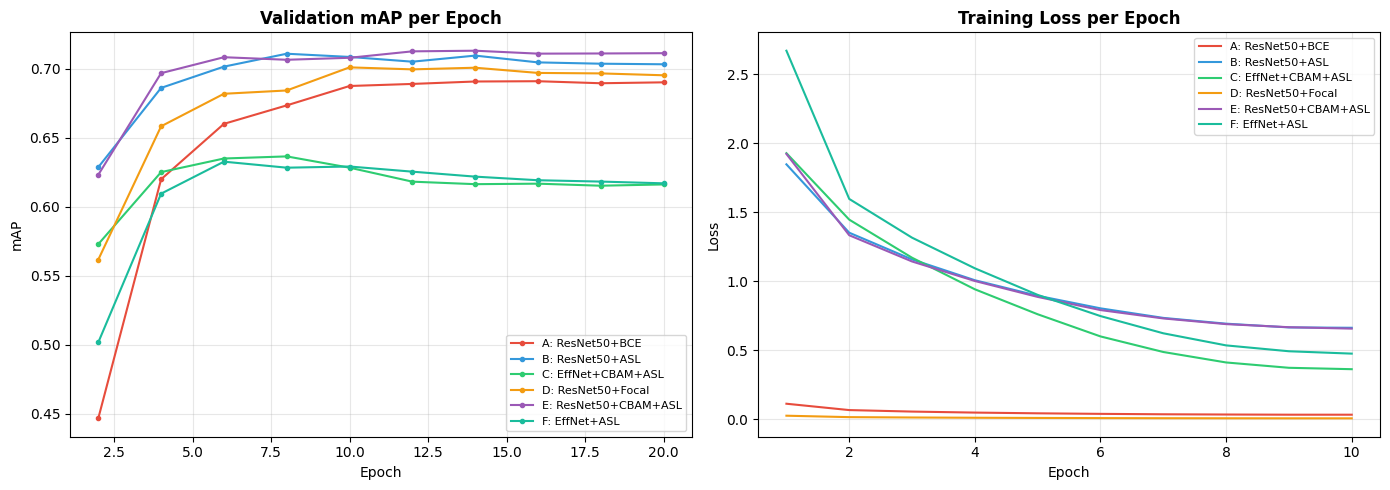

Saved ablation_curves.png


In [7]:
import matplotlib.pyplot as plt
from pathlib import Path

OUTPUTS_DIR = Path('/kaggle/working/outputs')
exp_list = [
    ('A: ResNet50+BCE',      'exp_A_resnet_bce'),
    ('B: ResNet50+ASL',      'exp_B_resnet_asl'),
    ('C: EffNet+CBAM+ASL',   'exp_C_efficientnet_cbam_asl'),
    ('D: ResNet50+Focal',    'exp_D_resnet_focal'),
    ('E: ResNet50+CBAM+ASL', 'exp_E_resnet_cbam_asl'),
    ('F: EffNet+ASL',        'exp_F_efficientnet_asl'),
    ('G: EffNet+CBAM+ASL+AThres', 'exp_G'),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#e74c3c','#3498db','#2ecc71','#f39c12','#9b59b6','#1abc9c']

for (name, exp_dir), color in zip(exp_list, colors):
    log_path = OUTPUTS_DIR / exp_dir / 'log.json'
    if not log_path.exists():
        continue
    records = json.load(open(log_path))
    epochs = [r['epoch'] for r in records if 'mAP' in r]
    maps   = [r['mAP']   for r in records if 'mAP' in r]
    losses = [r.get('train_loss', None) for r in records]

    axes[0].plot(epochs, maps, marker='o', ms=3, label=name, color=color)
    train_epochs = list(range(1, len(losses)+1))
    axes[1].plot(train_epochs, losses, label=name, color=color)

axes[0].set_title('Validation mAP per Epoch', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('mAP')
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

axes[1].set_title('Training Loss per Epoch', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(str(OUTPUTS_DIR / 'ablation_curves.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved ablation_curves.png')


## Cell 16: Cross-Dataset Evaluation (Pascal VOC 2012)

**Thêm data:** Add Data → gopalbhattrai/pascal-voc-2012-dataset


In [8]:
import os
from pathlib import Path

VOC_ROOT    = '/kaggle/input/datasets/gopalbhattrai/pascal-voc-2012-dataset/VOC2012_test/VOC2012_test'
OUTPUTS_DIR = '/kaggle/working/outputs'

if os.path.exists(VOC_ROOT):
    print('Starting VOC 2012 cross-evaluation...')
    !python /kaggle/working/ECAAL/src/cross_evaluate.py --voc-root {VOC_ROOT} --outputs-dir {OUTPUTS_DIR}
else:
    print(f'VOC dataset not found at {VOC_ROOT}')
    print('Add Data -> gopalbhattrai/pascal-voc-2012-dataset')


Starting VOC 2012 cross-evaluation...
[VOC 2012 test] 10,991 images loaded

Đang đánh giá VOC cho: exp_F_efficientnet_asl
[Model] efficientnet_b0 | CBAM=False | Params=3.62M | FeatChannels=320
DEBUG: Mapping size: 20 (Expected: 20)
exp_F_efficientnet_asl: VOC mAP = 0.0000

Đang đánh giá VOC cho: exp_D_resnet_focal
[Model] resnet50 | CBAM=False | Params=23.67M | FeatChannels=2048
DEBUG: Mapping size: 20 (Expected: 20)
exp_D_resnet_focal: VOC mAP = 0.0000

Đang đánh giá VOC cho: exp_C_efficientnet_cbam_asl
[Model] efficientnet_b0 | CBAM=True | Params=3.63M | FeatChannels=320
DEBUG: Mapping size: 20 (Expected: 20)
exp_C_efficientnet_cbam_asl: VOC mAP = 0.0000

Đang đánh giá VOC cho: exp_A_resnet_bce
[Model] resnet50 | CBAM=False | Params=23.67M | FeatChannels=2048
DEBUG: Mapping size: 20 (Expected: 20)
exp_A_resnet_bce: VOC mAP = 0.0000

Đang đánh giá VOC cho: exp_E_resnet_cbam_asl
[Model] resnet50 | CBAM=True | Params=24.20M | FeatChannels=2048
DEBUG: Mapping size: 20 (Expected: 20)
exp_

## Cell 17: COCO Test Evaluation (4k held-out from val2017)


In [9]:
import torch, json
import numpy as np
import pandas as pd
from pathlib import Path
import sys

sys.path.insert(0, str(REPO_DIR / 'src'))
from models import build_model
from dataset import COCOMultiLabelDataset, get_val_transform
from evaluate import compute_map, compute_f1

COCO_ROOT   = '/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017'
OUTPUTS_DIR = Path('/kaggle/working/outputs')
SUBSET_DIR  = Path('/kaggle/working/data/coco_subset')
DEVICE      = 'cuda'

test_ids = json.load(open(SUBSET_DIR / 'subset_test_ids.json'))
print(f'Test set: {len(test_ids)} images from val2017')

transform   = get_val_transform(img_size=224)
test_ds     = COCOMultiLabelDataset(COCO_ROOT, 'val', transform, test_ids)
test_loader = torch.utils.data.DataLoader(test_ds, batch_size=64, num_workers=2, pin_memory=True)

EXPERIMENTS = [
    ('A: ResNet50+BCE',      'exp_A_resnet_bce',            'resnet50',        False),
    ('B: ResNet50+ASL',      'exp_B_resnet_asl',            'resnet50',        False),
    ('C: EffNet+CBAM+ASL',   'exp_C_efficientnet_cbam_asl', 'efficientnet_b0', True),
    ('D: ResNet50+Focal',    'exp_D_resnet_focal',          'resnet50',        False),
    ('E: ResNet50+CBAM+ASL', 'exp_E_resnet_cbam_asl',       'resnet50',        True),
    ('F: EffNet+ASL',        'exp_F_efficientnet_asl',      'efficientnet_b0', False),
    ('G: EffNet+CBAM+ASL+AThres', 'exp_G', 'efficientnet_b0', True),
]

coco_test_results = []
for name, exp_dir, backbone, use_cbam in EXPERIMENTS:
    pth = OUTPUTS_DIR / exp_dir / 'best.pth'
    if not pth.exists():
        print(f'  skip {name} (no best.pth)'); continue
    print(f'\nEvaluating COCO test: {name}')
    model = build_model({'backbone': backbone, 'use_cbam': use_cbam,
                         'num_classes': 80, 'pretrained': False}).to(DEVICE)
    ckpt = torch.load(pth, map_location=DEVICE, weights_only=False)
    model.load_state_dict(ckpt['model'] if isinstance(ckpt, dict) and 'model' in ckpt else ckpt)
    model.eval()
    all_p, all_t = [], []
    with torch.no_grad():
        for imgs, tgts in test_loader:
            p = torch.sigmoid(model(imgs.to(DEVICE))).cpu().numpy()
            all_p.append(p); all_t.append(tgts.numpy())
    P = np.concatenate(all_p); T = np.concatenate(all_t)
    m = {**compute_map(T, P), **compute_f1(T, P)}
    coco_test_results.append({
        'Experiment': name, 'exp_dir': exp_dir,
        'COCO_Test_mAP': round(m['mAP'], 4),
        'COCO_Test_Macro_F1': round(m['macro_f1'], 4),
        'COCO_Test_Micro_F1': round(m['micro_f1'], 4),
    })
    print(f"  mAP={m['mAP']:.4f} | F1={m['macro_f1']:.4f}")

df = pd.DataFrame([{k:v for k,v in r.items() if k!='exp_dir'} for r in coco_test_results])
df.to_csv(OUTPUTS_DIR / 'coco_test_evaluation.csv', index=False)
print('\n' + '='*65)
print('COCO TEST RESULTS (4k held-out from val2017)')
print('='*65)
print(df.to_string(index=False))
print('='*65)


Test set: 3952 images from val2017
[COCO 2017 val] 3,952 images loaded

Evaluating COCO test: A: ResNet50+BCE
[Model] resnet50 | CBAM=False | Params=23.67M | FeatChannels=2048
  mAP=0.7081 | F1=0.6836

Evaluating COCO test: B: ResNet50+ASL
[Model] resnet50 | CBAM=False | Params=23.67M | FeatChannels=2048
  mAP=0.7228 | F1=0.6927

Evaluating COCO test: C: EffNet+CBAM+ASL
[Model] efficientnet_b0 | CBAM=True | Params=3.63M | FeatChannels=320
  mAP=0.6537 | F1=0.6407

Evaluating COCO test: D: ResNet50+Focal
[Model] resnet50 | CBAM=False | Params=23.67M | FeatChannels=2048
  mAP=0.7100 | F1=0.6858

Evaluating COCO test: E: ResNet50+CBAM+ASL
[Model] resnet50 | CBAM=True | Params=24.20M | FeatChannels=2048
  mAP=0.7223 | F1=0.6961

Evaluating COCO test: F: EffNet+ASL
[Model] efficientnet_b0 | CBAM=False | Params=3.62M | FeatChannels=320
  mAP=0.6463 | F1=0.6281

Evaluating COCO test: G: EffNet+CBAM+ASL+AThres
[Model] efficientnet_b0 | CBAM=True | Params=3.63M | FeatChannels=320
  mAP=0.6076 |

## Cell 18: Cross-Dataset Comparison — VOC vs COCO Test



CROSS-DATASET: COCO Test vs VOC (cross-dataset)
               Experiment  COCO_Test_mAP  COCO_Test_Macro_F1  VOC_mAP  VOC_Macro_F1
          B: ResNet50+ASL         0.7228              0.6927      0.0           0.0
     E: ResNet50+CBAM+ASL         0.7223              0.6961      0.0           0.0
        D: ResNet50+Focal         0.7100              0.6858      0.0           0.0
          A: ResNet50+BCE         0.7081              0.6836      0.0           0.0
       C: EffNet+CBAM+ASL         0.6537              0.6407      0.0           0.0
            F: EffNet+ASL         0.6463              0.6281      0.0           0.0
G: EffNet+CBAM+ASL+AThres         0.6076              0.5947      NaN           NaN
   G: EffNet+CBAM+ASL+CWT            NaN                 NaN      0.0           0.0


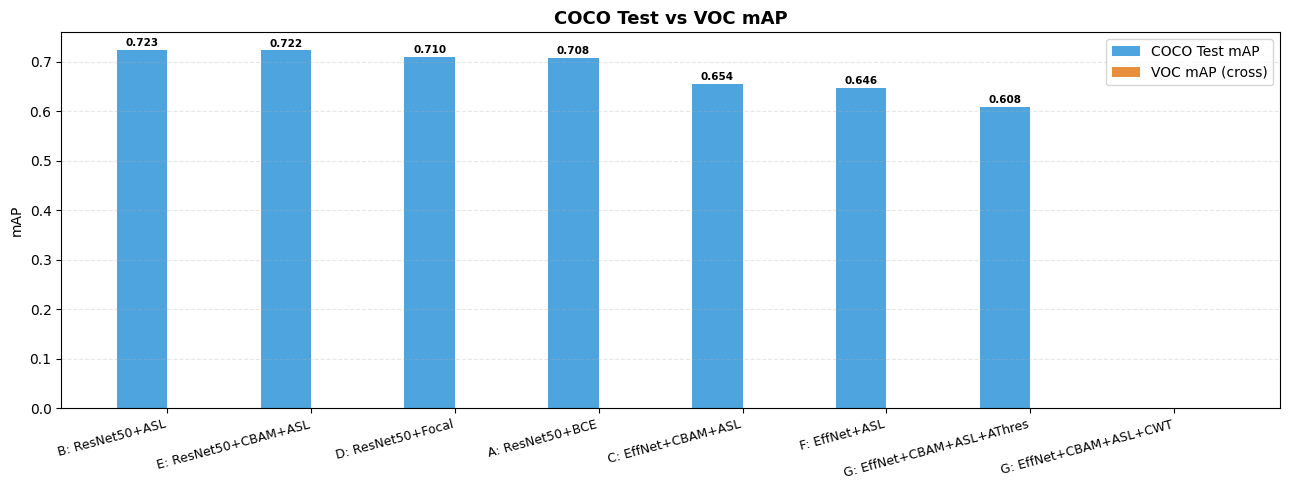

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

OUTPUTS_DIR = Path('/kaggle/working/outputs')
voc_csv  = OUTPUTS_DIR / 'voc_cross_evaluation.csv'
coco_csv = OUTPUTS_DIR / 'coco_test_evaluation.csv'

if not voc_csv.exists() or not coco_csv.exists():
    missing = []
    if not voc_csv.exists():  missing.append('voc (Cell 16)')
    if not coco_csv.exists(): missing.append('coco_test (Cell 17)')
    print(f'Missing: {", ".join(missing)}')
else:
    df_voc  = pd.read_csv(voc_csv)
    df_coco = pd.read_csv(coco_csv)

    name_map = {
        'exp_A_resnet_bce':           'A: ResNet50+BCE',
        'exp_B_resnet_asl':           'B: ResNet50+ASL',
        'exp_C_efficientnet_cbam_asl':'C: EffNet+CBAM+ASL',
        'exp_D_resnet_focal':         'D: ResNet50+Focal',
        'exp_E_resnet_cbam_asl':      'E: ResNet50+CBAM+ASL',
        'exp_F_efficientnet_asl':     'F: EffNet+ASL',
        'exp_G':                      'G: EffNet+CBAM+ASL+CWT',
    }
    if df_voc['Experiment'].str.startswith('exp_').any():
        df_voc['Experiment'] = df_voc['Experiment'].map(lambda x: name_map.get(x, x))

    df_m = df_coco[['Experiment','COCO_Test_mAP','COCO_Test_Macro_F1']].merge(
        df_voc[['Experiment','VOC_mAP','VOC_Macro_F1']], on='Experiment', how='outer'
    ).sort_values('COCO_Test_mAP', ascending=False).reset_index(drop=True)

    print('\n' + '='*75)
    print('CROSS-DATASET: COCO Test vs VOC (cross-dataset)')
    print('='*75)
    print(df_m.to_string(index=False))
    print('='*75)
    df_m.to_csv(OUTPUTS_DIR / 'cross_dataset_comparison.csv', index=False)

    fig, ax = plt.subplots(figsize=(13, 5))
    x = range(len(df_m)); w = 0.35
    b1 = ax.bar([i-w/2 for i in x], df_m['COCO_Test_mAP'].fillna(0), w,
                label='COCO Test mAP', color='#3498db', alpha=0.88)
    b2 = ax.bar([i+w/2 for i in x], df_m['VOC_mAP'].fillna(0), w,
                label='VOC mAP (cross)', color='#e67e22', alpha=0.88)
    ax.set_xticks(list(x))
    ax.set_xticklabels(df_m['Experiment'], rotation=15, ha='right', fontsize=9)
    ax.set_ylabel('mAP'); ax.set_title('COCO Test vs VOC mAP', fontsize=13, fontweight='bold')
    ax.legend(); ax.grid(axis='y', alpha=0.3, linestyle='--')
    for bar in list(b1)+list(b2):
        h = bar.get_height()
        if h > 0: ax.text(bar.get_x()+bar.get_width()/2, h+0.004, f'{h:.3f}',
                          ha='center', va='bottom', fontsize=7.5, fontweight='bold')
    plt.tight_layout()
    plt.savefig(str(OUTPUTS_DIR / 'cross_dataset_bar.png'), dpi=150, bbox_inches='tight')
    plt.show()


## Cell 19: Overfitting Analysis — Train vs Val vs Test


In [11]:
import torch, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import sys

sys.path.insert(0, str(REPO_DIR / 'src'))
from models import build_model
from dataset import COCOMultiLabelDataset, get_val_transform
from evaluate import compute_map, compute_f1

COCO_ROOT   = '/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017'
OUTPUTS_DIR = Path('/kaggle/working/outputs')
SUBSET_DIR  = Path('/kaggle/working/data/coco_subset')
DEVICE      = 'cuda'

transform = get_val_transform(img_size=224)
train_ids = json.load(open(SUBSET_DIR / 'subset_train_ids.json'))
train_ds  = COCOMultiLabelDataset(COCO_ROOT, 'train', transform, train_ids)
print(f'Train eval: {len(train_ds.samples)} samples')
train_loader = torch.utils.data.DataLoader(train_ds, batch_size=64, num_workers=2, pin_memory=True)

EXPERIMENTS = [
    ('A: ResNet50+BCE',      'exp_A_resnet_bce',            'resnet50',        False),
    ('B: ResNet50+ASL',      'exp_B_resnet_asl',            'resnet50',        False),
    ('C: EffNet+CBAM+ASL',   'exp_C_efficientnet_cbam_asl', 'efficientnet_b0', True),
    ('D: ResNet50+Focal',    'exp_D_resnet_focal',          'resnet50',        False),
    ('E: ResNet50+CBAM+ASL', 'exp_E_resnet_cbam_asl',       'resnet50',        True),
    ('F: EffNet+ASL',        'exp_F_efficientnet_asl',      'efficientnet_b0', False),
    ('G: EffNet+CBAM+ASL+AThres', 'exp_G', 'efficientnet_b0', True),
]

coco_test_csv = OUTPUTS_DIR / 'coco_test_evaluation.csv'
df_test = pd.read_csv(coco_test_csv) if coco_test_csv.exists() else None

rows = []
for name, exp_dir, backbone, use_cbam in EXPERIMENTS:
    pth = OUTPUTS_DIR / exp_dir / 'best.pth'
    log = OUTPUTS_DIR / exp_dir / 'log.json'
    if not pth.exists(): continue
    print(f'\nTrain-eval: {name}')
    model = build_model({'backbone': backbone, 'use_cbam': use_cbam,
                         'num_classes': 80, 'pretrained': False}).to(DEVICE)
    ckpt = torch.load(pth, map_location=DEVICE, weights_only=False)
    model.load_state_dict(ckpt['model'] if isinstance(ckpt, dict) and 'model' in ckpt else ckpt)
    model.eval()
    all_p, all_t = [], []
    with torch.no_grad():
        for imgs, tgts in train_loader:
            p = torch.sigmoid(model(imgs.to(DEVICE))).cpu().numpy()
            all_p.append(p); all_t.append(tgts.numpy())
    P = np.concatenate(all_p); T = np.concatenate(all_t)
    tr = {**compute_map(T, P), **compute_f1(T, P)}

    val_map = val_f1 = None
    if log.exists():
        best = max(json.load(open(log)), key=lambda r: r.get('mAP', 0))
        val_map = round(best.get('mAP', 0), 4)
        val_f1  = round(best.get('macro_f1', 0), 4)

    test_map = test_f1 = None
    if df_test is not None:
        r = df_test[df_test['Experiment'] == name]
        if not r.empty:
            test_map = r.iloc[0].get('COCO_Test_mAP')
            test_f1  = r.iloc[0].get('COCO_Test_Macro_F1')

    train_map = round(tr['mAP'], 4)
    gap_test  = round(train_map - test_map, 4) if test_map else None

    def status(g):
        if g is None: return '?'
        return 'OK' if abs(g) < 0.04 else ('Nhe' if abs(g) < 0.08 else 'OVERFIT')

    print(f'  Train={train_map:.4f} Val={val_map} Test={test_map} Gap={gap_test} {status(gap_test)}')
    rows.append({
        'Experiment': name,
        'Train_mAP': train_map, 'Val_mAP': val_map, 'Test_mAP': test_map,
        'Gap_test': gap_test,
        'Train_F1': round(tr['macro_f1'], 4), 'Val_F1': val_f1, 'Test_F1': test_f1,
    })

if not rows:
    print('No results')
else:
    df = pd.DataFrame(rows).sort_values('Test_mAP', ascending=False, na_position='last').reset_index(drop=True)
    print('\n' + '='*80)
    print('OVERFITTING ANALYSIS: Train vs Val vs Test')
    print('='*80)
    print(df[['Experiment','Train_mAP','Val_mAP','Test_mAP','Gap_test']].to_string(index=False))
    print('='*80)
    for _, r in df.iterrows():
        g = r['Gap_test']
        if g is not None:
            s = 'OK' if abs(g)<0.04 else ('Nhe' if abs(g)<0.08 else 'OVERFIT')
            print(f"  {r['Experiment']:<28} gap={g:+.4f}  {s}")
    df.to_csv(OUTPUTS_DIR / 'overfitting_analysis.csv', index=False)
    print('Saved overfitting_analysis.csv')


[COCO 2017 train] 16,000 images loaded
Train eval: 16000 samples

Train-eval: A: ResNet50+BCE
[Model] resnet50 | CBAM=False | Params=23.67M | FeatChannels=2048
  Train=0.8706 Val=0.6908 Test=0.7081 Gap=0.1625 OVERFIT

Train-eval: B: ResNet50+ASL
[Model] resnet50 | CBAM=False | Params=23.67M | FeatChannels=2048
  Train=0.8739 Val=0.7107 Test=0.7228 Gap=0.1511 OVERFIT

Train-eval: C: EffNet+CBAM+ASL
[Model] efficientnet_b0 | CBAM=True | Params=3.63M | FeatChannels=320
  Train=0.9168 Val=0.6364 Test=0.6537 Gap=0.2631 OVERFIT

Train-eval: D: ResNet50+Focal
[Model] resnet50 | CBAM=False | Params=23.67M | FeatChannels=2048
  Train=0.8665 Val=0.7009 Test=0.71 Gap=0.1565 OVERFIT

Train-eval: E: ResNet50+CBAM+ASL
[Model] resnet50 | CBAM=True | Params=24.20M | FeatChannels=2048
  Train=0.9310 Val=0.7129 Test=0.7223 Gap=0.2087 OVERFIT

Train-eval: F: EffNet+ASL
[Model] efficientnet_b0 | CBAM=False | Params=3.62M | FeatChannels=320
  Train=0.8132 Val=0.6326 Test=0.6463 Gap=0.1669 OVERFIT

Train-ev

## Cell 20: Sample Prediction Visualization (worst FP+FN)


[COCO 2017 val] 3,952 images loaded

=== Visualizing: C: EffNet+CBAM+ASL ===
[Model] efficientnet_b0 | CBAM=True | Params=3.63M | FeatChannels=320


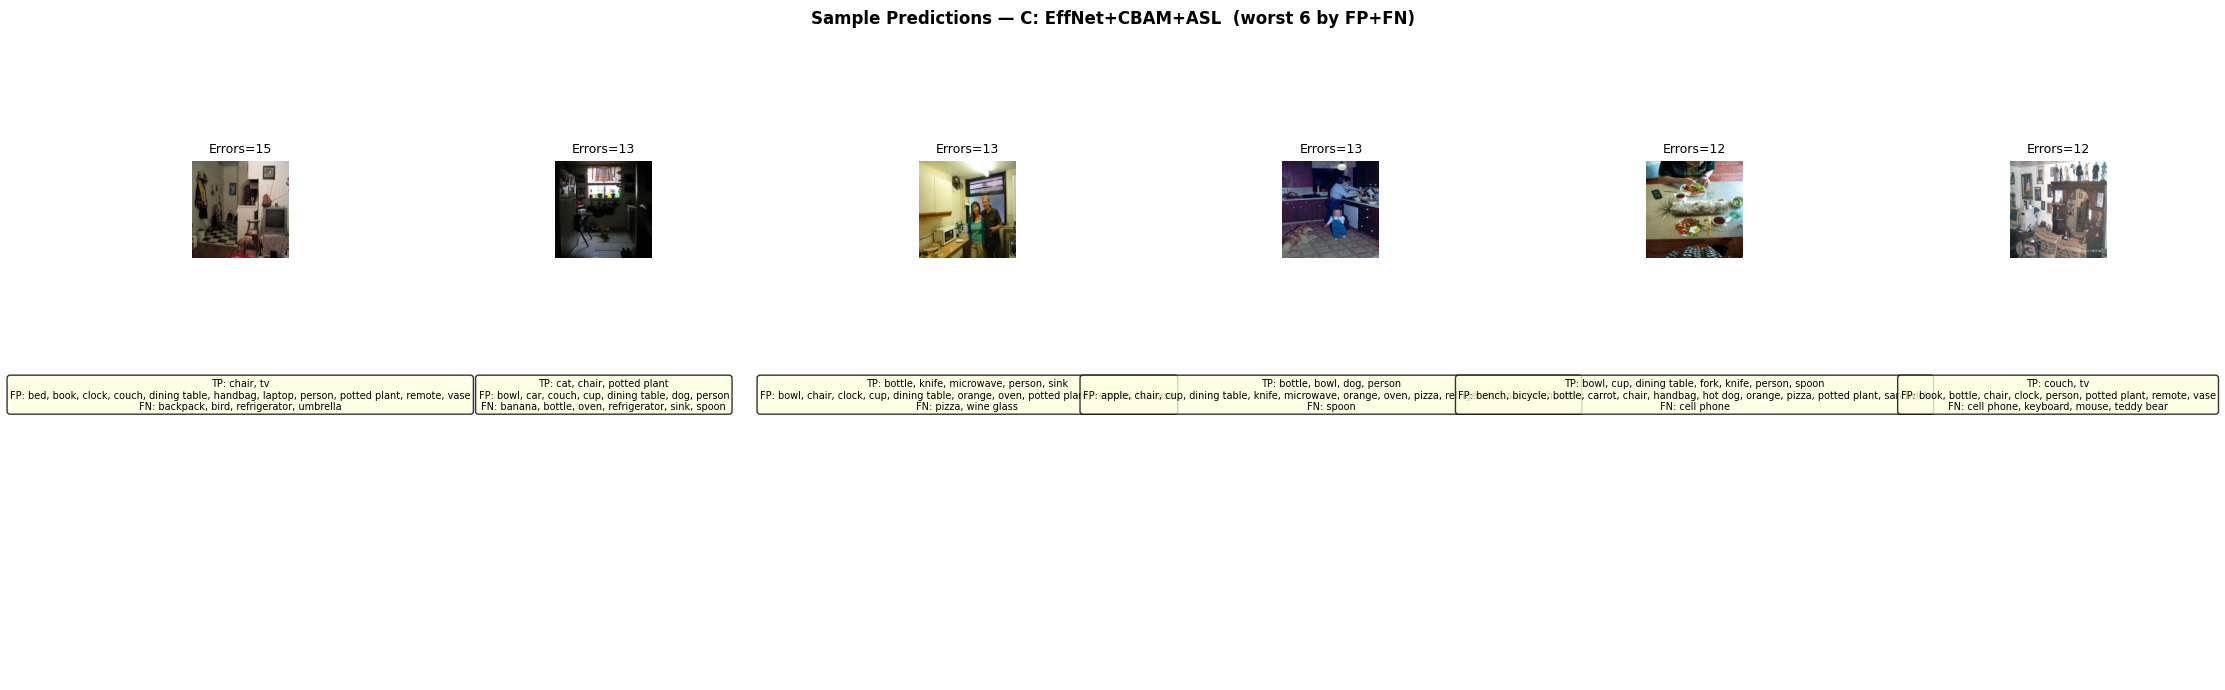

Saved: /kaggle/working/outputs/vis_samples_exp_C_efficientnet_cbam_asl.png

=== Visualizing: G: EffNet+CBAM+ASL+AThres ===
[Model] efficientnet_b0 | CBAM=True | Params=3.63M | FeatChannels=320


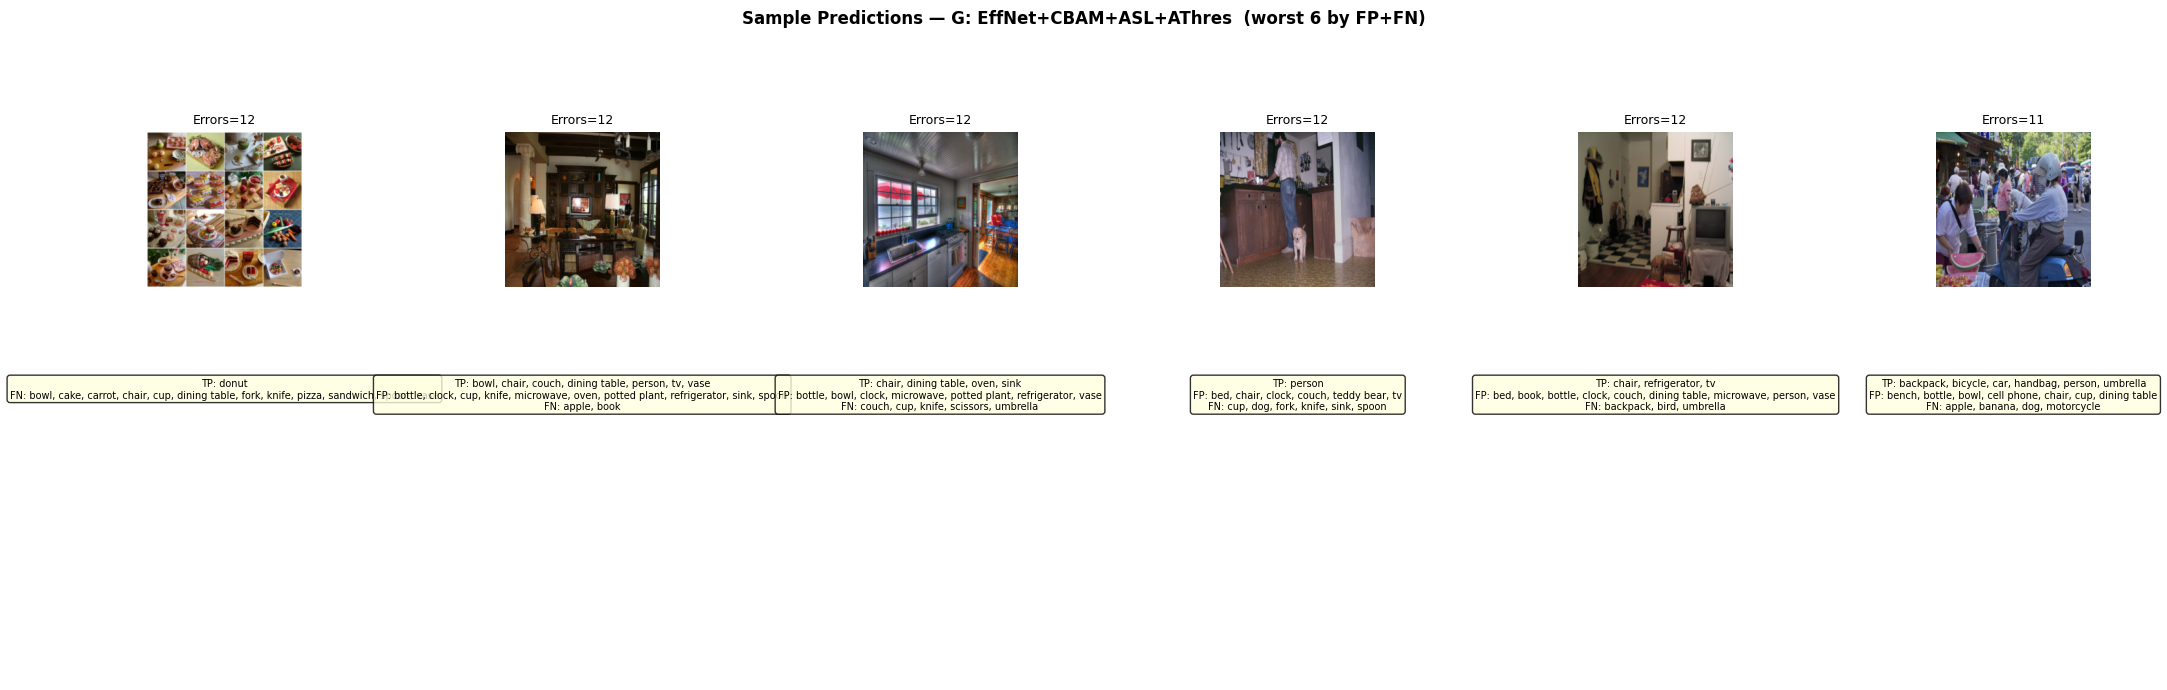

Saved: /kaggle/working/outputs/vis_samples_exp_G.png

=== Visualizing: B: ResNet50+ASL ===
[Model] resnet50 | CBAM=False | Params=23.67M | FeatChannels=2048


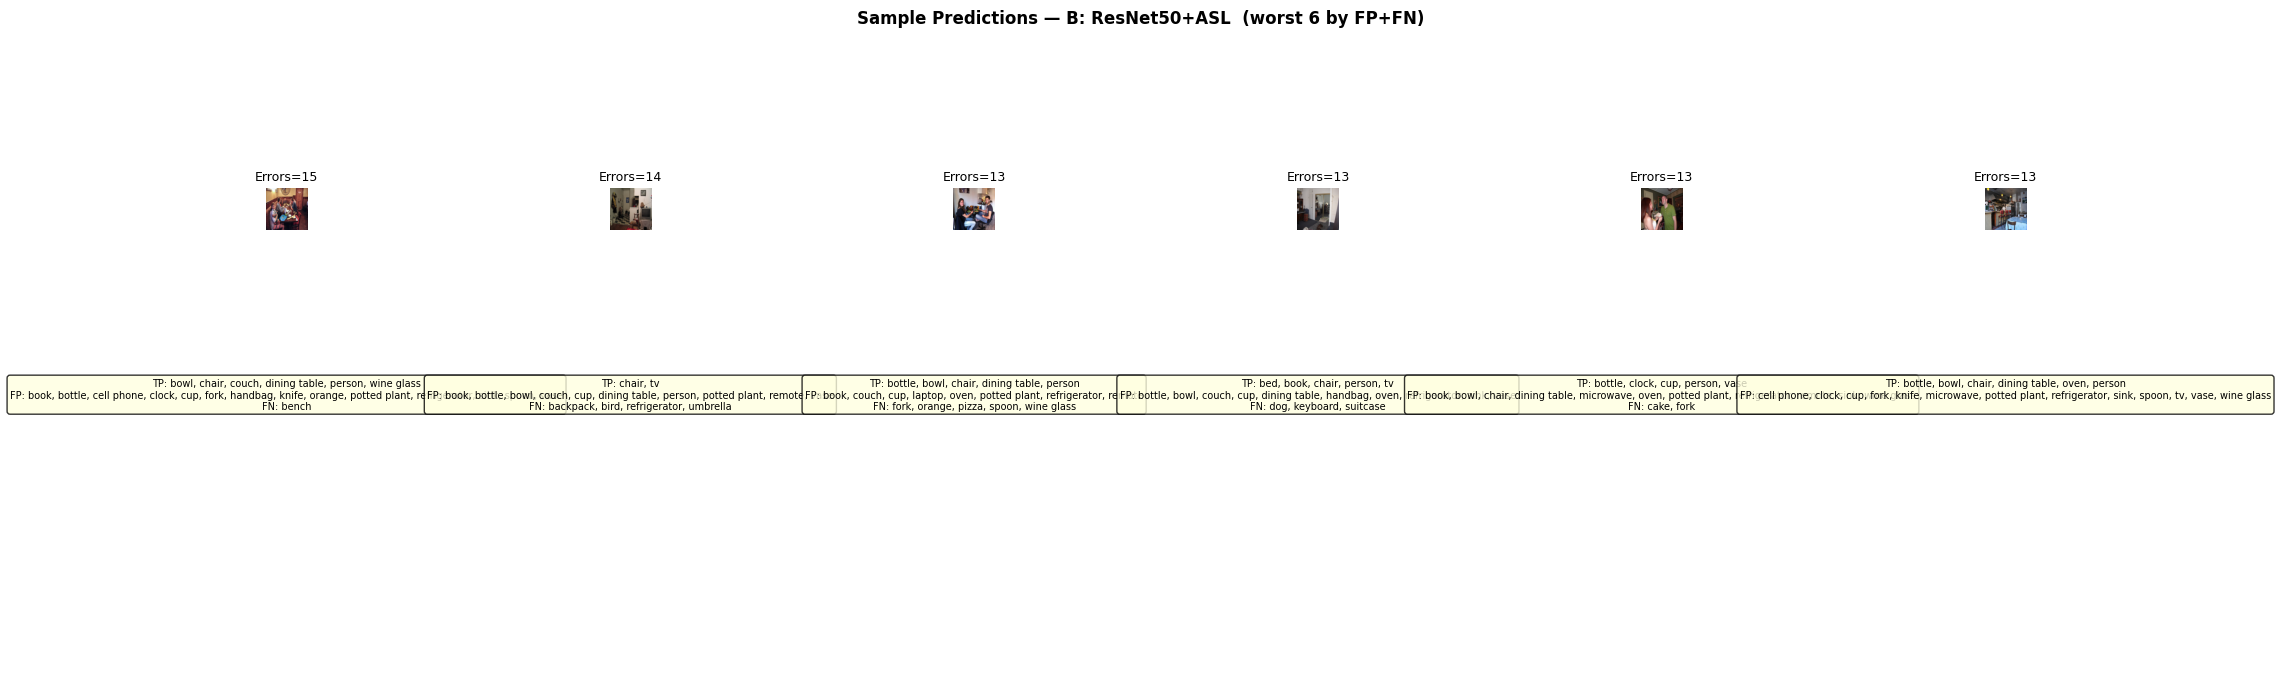

Saved: /kaggle/working/outputs/vis_samples_exp_B_resnet_asl.png


In [12]:
import torch, json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys

sys.path.insert(0, str(REPO_DIR / 'src'))
from models import build_model
from dataset import COCOMultiLabelDataset, get_val_transform

COCO_ROOT   = '/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017'
OUTPUTS_DIR = Path('/kaggle/working/outputs')
SUBSET_DIR  = Path('/kaggle/working/data/coco_subset')
DEVICE      = 'cuda'

COCO_CATS = [
    'person','bicycle','car','motorcycle','airplane','bus','train','truck','boat','traffic light',
    'fire hydrant','stop sign','parking meter','bench','bird','cat','dog','horse','sheep','cow',
    'elephant','bear','zebra','giraffe','backpack','umbrella','handbag','tie','suitcase','frisbee',
    'skis','snowboard','sports ball','kite','baseball bat','baseball glove','skateboard','surfboard',
    'tennis racket','bottle','wine glass','cup','fork','knife','spoon','bowl','banana','apple',
    'sandwich','orange','broccoli','carrot','hot dog','pizza','donut','cake','chair','couch',
    'potted plant','bed','dining table','toilet','tv','laptop','mouse','remote','keyboard',
    'cell phone','microwave','oven','toaster','sink','refrigerator','book','clock','vase',
    'scissors','teddy bear','hair drier','toothbrush'
]

EXPERIMENTS_VIS = [
    ('C: EffNet+CBAM+ASL',        'exp_C_efficientnet_cbam_asl', 'efficientnet_b0', True),
    ('G: EffNet+CBAM+ASL+AThres', 'exp_G', 'efficientnet_b0', True),
    ('B: ResNet50+ASL',           'exp_B_resnet_asl',            'resnet50',        False),
]

THRESHOLD = 0.5
N_SAMPLES  = 6  # worst-case images per experiment

transform = get_val_transform(img_size=224)
test_ids  = json.load(open(SUBSET_DIR / 'subset_test_ids.json'))
test_ds   = COCOMultiLabelDataset(COCO_ROOT, 'val', transform, test_ids)

def denormalize(tensor):
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    img  = tensor.permute(1,2,0).numpy()
    img  = img * std + mean
    return np.clip(img, 0, 1)

def visualize_samples(name, exp_dir, backbone, use_cbam):
    pth = OUTPUTS_DIR / exp_dir / 'best.pth'
    if not pth.exists():
        print(f'Skip {name}: no best.pth'); return
    model = build_model({'backbone': backbone, 'use_cbam': use_cbam,
                         'num_classes': 80, 'pretrained': False}).to(DEVICE)
    ckpt  = torch.load(pth, map_location=DEVICE, weights_only=False)
    model.load_state_dict(ckpt['model'] if isinstance(ckpt, dict) and 'model' in ckpt else ckpt)
    model.eval()

    errors = []
    with torch.no_grad():
        for idx in range(min(500, len(test_ds))):
            img_t, target = test_ds[idx]
            logit = model(img_t.unsqueeze(0).to(DEVICE))
            prob  = torch.sigmoid(logit).squeeze().cpu().numpy()
            pred  = (prob >= THRESHOLD).astype(float)
            gt    = target.numpy()
            err   = int(np.sum(np.abs(pred - gt)))
            errors.append((err, idx, img_t, gt, prob, pred))

    errors.sort(key=lambda x: -x[0])
    worst = errors[:N_SAMPLES]

    fig, axes = plt.subplots(2, N_SAMPLES, figsize=(N_SAMPLES * 3.5, 7))
    fig.suptitle(f'Sample Predictions — {name}  (worst {N_SAMPLES} by FP+FN)', fontsize=12, fontweight='bold')

    for col, (err, idx, img_t, gt, prob, pred) in enumerate(worst):
        img_np = denormalize(img_t)
        gt_labels   = [COCO_CATS[i] for i in range(80) if gt[i]   > 0.5]
        pred_labels = [COCO_CATS[i] for i in range(80) if pred[i] > 0.5]
        tp = set(gt_labels) & set(pred_labels)
        fp = set(pred_labels) - set(gt_labels)
        fn = set(gt_labels)   - set(pred_labels)

        axes[0, col].imshow(img_np)
        axes[0, col].axis('off')
        axes[0, col].set_title(f'Errors={err}', fontsize=9)

        axes[1, col].axis('off')
        txt = ''
        if tp: txt += 'TP: ' + ', '.join(sorted(tp)) + '\n'
        if fp: txt += 'FP: ' + ', '.join(sorted(fp)) + '\n'
        if fn: txt += 'FN: ' + ', '.join(sorted(fn))
        axes[1, col].text(0.5, 0.98, txt, ha='center', va='top', fontsize=7,
                          transform=axes[1, col].transAxes,
                          bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))

    plt.tight_layout()
    save_path = OUTPUTS_DIR / f'vis_samples_{exp_dir}.png'
    plt.savefig(str(save_path), dpi=120, bbox_inches='tight')
    plt.show()
    print(f'Saved: {save_path}')

for name, exp_dir, backbone, use_cbam in EXPERIMENTS_VIS:
    print(f'\n=== Visualizing: {name} ===')
    visualize_samples(name, exp_dir, backbone, use_cbam)

## Co-occurrence Heatmap (Multi-label Confusion Matrix)


[COCO 2017 train] 16,000 images loaded
Train labels loaded: (16000, 80)


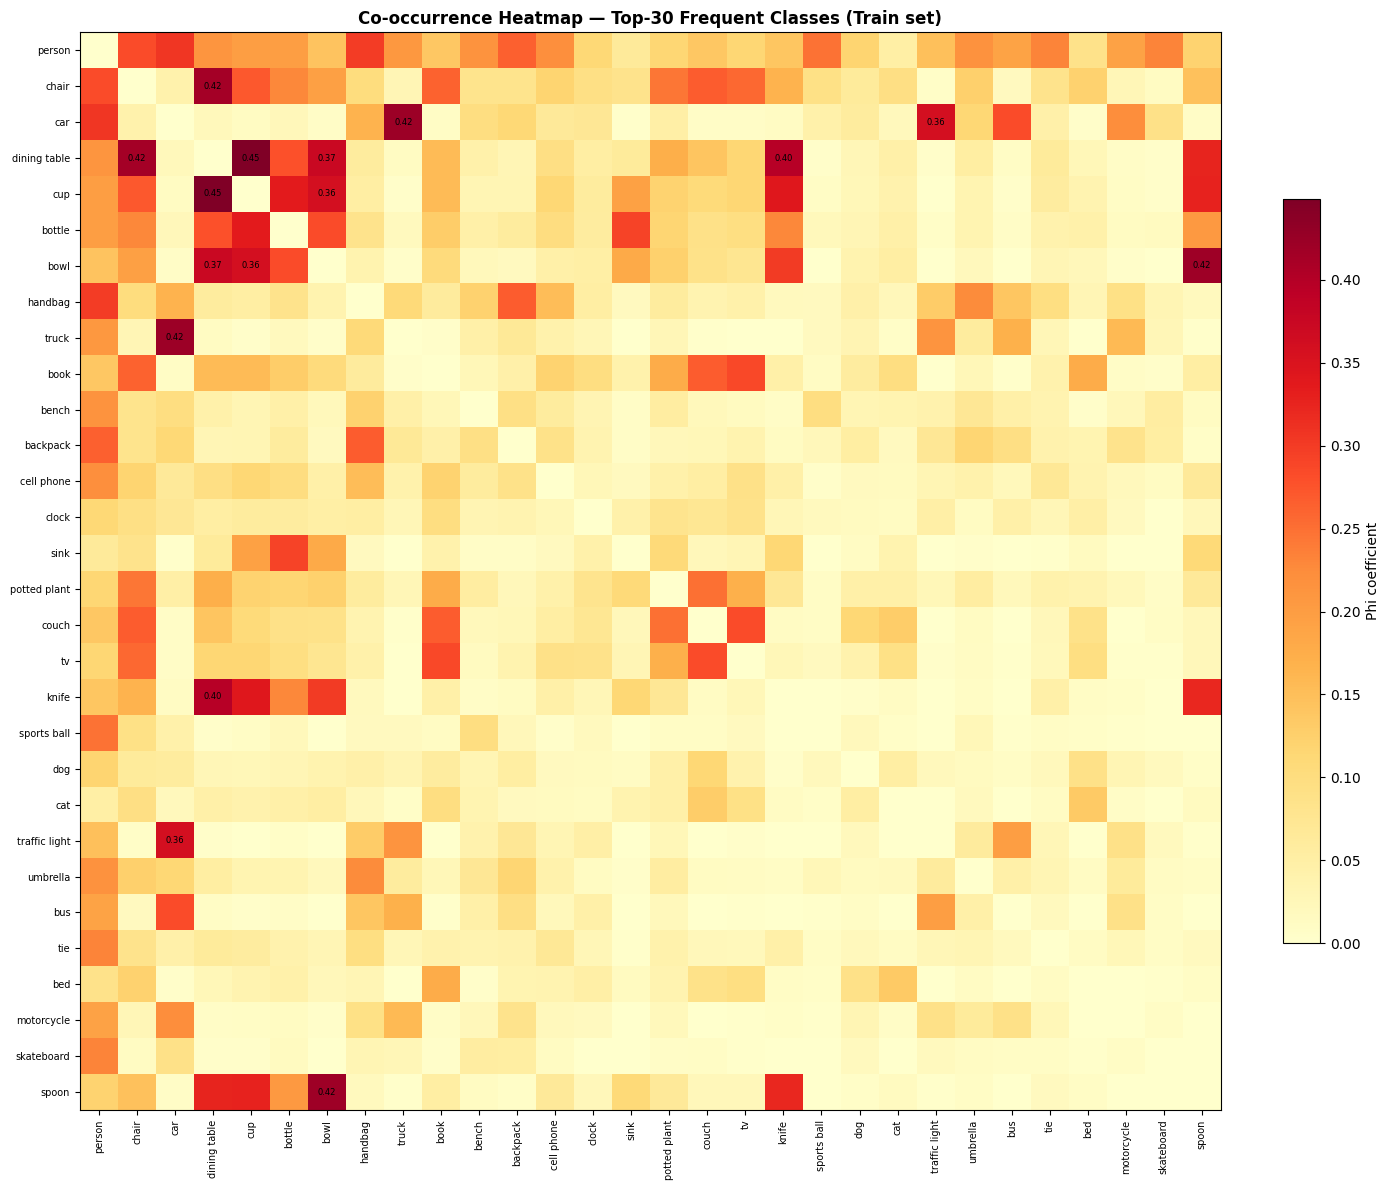

Top-10 co-occurring pairs:
  baseball bat         <-> baseball glove        phi=0.686
  mouse                <-> keyboard              phi=0.630
  toilet               <-> sink                  phi=0.488
  sports ball          <-> tennis racket         phi=0.483
  microwave            <-> oven                  phi=0.450
  cup                  <-> dining table          phi=0.449
  fork                 <-> knife                 phi=0.441
  car                  <-> truck                 phi=0.421
  spoon                <-> bowl                  phi=0.420
  chair                <-> dining table          phi=0.415
[COCO 2017 val] 3,952 images loaded
[Model] efficientnet_b0 | CBAM=True | Params=3.63M | FeatChannels=320

Top-10 FP confusion pairs:
  Predict [chair               ] when GT=[person              ]  count=297
  Predict [backpack            ] when GT=[person              ]  count=262
  Predict [handbag             ] when GT=[person              ]  count=250
  Predict [bottle       

In [13]:
# ── Co-occurrence Heatmap ────────────────────────────────────
# Multi-label: không có confusion matrix chuẩn.
# Thay bằng Phi-coefficient co-occurrence giữa các cặp class.
import numpy as np, json, sys, torch
import matplotlib.pyplot as plt
from pathlib import Path

sys.path.insert(0, str(REPO_DIR / 'src'))
from dataset import COCOMultiLabelDataset, get_val_transform
from models import build_model

COCO_ROOT  = '/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017'
SUBSET_DIR = Path('/kaggle/working/data/coco_subset')
OUTPUTS_DIR= Path('/kaggle/working/outputs')
DEVICE     = 'cuda' if torch.cuda.is_available() else 'cpu'

COCO_CATS = [
    'person','bicycle','car','motorcycle','airplane','bus','train','truck','boat',
    'traffic light','fire hydrant','stop sign','parking meter','bench','bird',
    'cat','dog','horse','sheep','cow','elephant','bear','zebra','giraffe',
    'backpack','umbrella','handbag','tie','suitcase','frisbee','skis','snowboard',
    'sports ball','kite','baseball bat','baseball glove','skateboard','surfboard',
    'tennis racket','bottle','wine glass','cup','fork','knife','spoon','bowl',
    'banana','apple','sandwich','orange','broccoli','carrot','hot dog','pizza',
    'donut','cake','chair','couch','potted plant','bed','dining table','toilet',
    'tv','laptop','mouse','remote','keyboard','cell phone','microwave','oven',
    'toaster','sink','refrigerator','book','clock','vase','scissors','teddy bear',
    'hair drier','toothbrush'
]

# Load train labels
transform = get_val_transform(img_size=224)
train_ids = json.load(open(SUBSET_DIR / 'subset_train_ids.json'))
train_ds  = COCOMultiLabelDataset(COCO_ROOT, 'train', transform, train_ids)
labels = np.array([lbl.numpy() for _, lbl in train_ds])  # (N,80)
N = len(labels)
print(f'Train labels loaded: {labels.shape}')

# Phi co-occurrence
freq  = labels.sum(0) / N
cooc  = (labels.T @ labels) / N
denom = np.sqrt(np.outer(freq, freq))
denom[denom == 0] = 1
phi   = cooc / denom
np.fill_diagonal(phi, 0)

# Top-30 frequent classes
top30  = np.argsort(freq)[::-1][:30]
phi30  = phi[np.ix_(top30, top30)]
cats30 = [COCO_CATS[i] for i in top30]

fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(phi30, cmap='YlOrRd', aspect='auto')
ax.set_xticks(range(30)); ax.set_xticklabels(cats30, rotation=90, fontsize=7)
ax.set_yticks(range(30)); ax.set_yticklabels(cats30, fontsize=7)
plt.colorbar(im, ax=ax, fraction=0.03, label='Phi coefficient')
ax.set_title('Co-occurrence Heatmap — Top-30 Frequent Classes (Train set)',
             fontsize=12, fontweight='bold')
for i in range(30):
    for j in range(30):
        if phi30[i,j] > 0.35:
            ax.text(j, i, f'{phi30[i,j]:.2f}', ha='center', va='center', fontsize=6)
plt.tight_layout()
plt.savefig(str(OUTPUTS_DIR / 'cooccurrence_heatmap.png'), dpi=120)
plt.show()

pairs = sorted([(phi[i,j], COCO_CATS[i], COCO_CATS[j])
                for i in range(80) for j in range(i+1,80)], reverse=True)
print('Top-10 co-occurring pairs:')
for v,a,b in pairs[:10]: print(f'  {a:20s} <-> {b:20s}  phi={v:.3f}')

# FP analysis with Exp C
pth = OUTPUTS_DIR / 'exp_C_efficientnet_cbam_asl' / 'best.pth'
if pth.exists():
    test_ids = json.load(open(SUBSET_DIR / 'subset_test_ids.json'))
    test_ds  = COCOMultiLabelDataset(COCO_ROOT, 'val', transform, test_ids)
    loader   = torch.utils.data.DataLoader(test_ds, batch_size=64, num_workers=2)
    model    = build_model({'backbone':'efficientnet_b0','use_cbam':True,
                            'num_classes':80,'pretrained':False}).to(DEVICE)
    ckpt = torch.load(pth, map_location=DEVICE, weights_only=False)
    model.load_state_dict(ckpt['model'] if 'model' in ckpt else ckpt)
    model.eval()
    all_p, all_t = [], []
    with torch.no_grad():
        for imgs, tgts in loader:
            all_p.append(torch.sigmoid(model(imgs.to(DEVICE))).cpu().numpy())
            all_t.append(tgts.numpy())
    P = np.concatenate(all_p); T = np.concatenate(all_t)
    pred = (P >= 0.5).astype(int)
    FP_mat = np.zeros((80, 80), dtype=int)
    for n in range(len(T)):
        fp  = np.where((pred[n]==1) & (T[n]==0))[0]
        gt  = np.where(T[n]==1)[0]
        for f in fp:
            for g in gt: FP_mat[f, g] += 1
    fp_pairs = sorted([(FP_mat[i,j], COCO_CATS[i], COCO_CATS[j])
                       for i in range(80) for j in range(80) if i!=j and FP_mat[i,j]>0],
                      reverse=True)
    print('\nTop-10 FP confusion pairs:')
    for cnt,a,b in fp_pairs[:10]:
        print(f'  Predict [{a:20s}] when GT=[{b:20s}]  count={cnt}')
else:
    print('Exp C best.pth not found')

## t-SNE: Feature Space Visualization (GAP vectors, Exp C)


[Model] efficientnet_b0 | CBAM=True | Params=3.63M | FeatChannels=320
[COCO 2017 val] 1,000 images loaded
Features: (1000, 320), Labels: (1000, 80)
PCA 1280->50...
PCA variance: 77.2%
t-SNE 50->2 (may take ~2min)...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


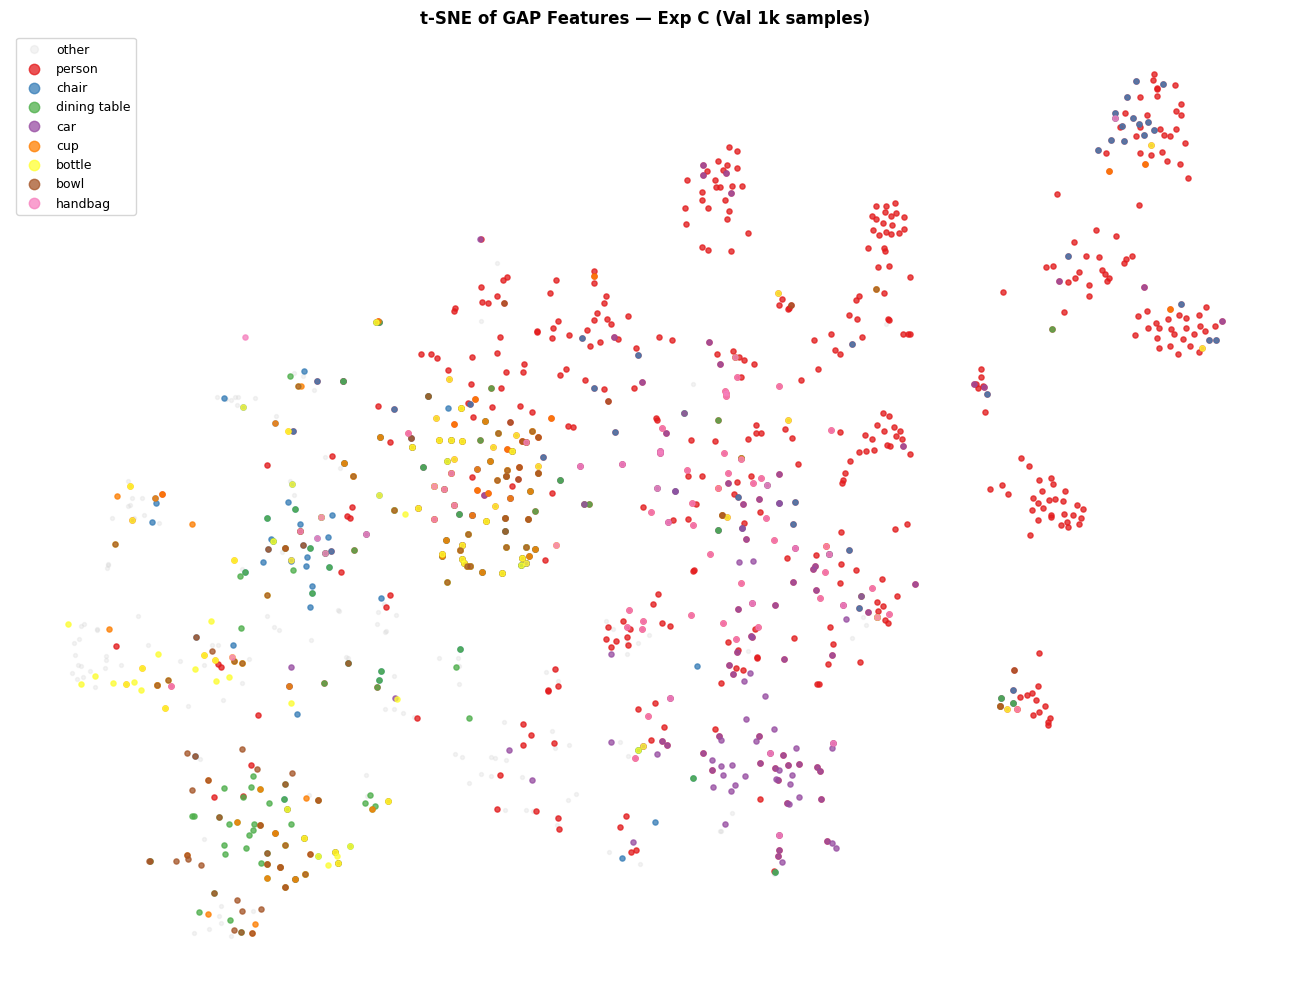

Saved: tsne_features_expC.png

Intra vs Inter cosine distance (top-5 classes):
  Class                    Intra     Inter  Overlap?
  person                  0.7896    0.9131  YES (confused)
  chair                   0.8043    0.8552  YES (confused)
  dining table            0.7754    0.8725  YES (confused)
  car                     0.7249    0.8809  YES (confused)
  cup                     0.7665    0.8550  YES (confused)


In [14]:
# ── t-SNE Feature Space Visualization ────────────────────────
# Extract GAP vectors (1280-dim) -> PCA(50) -> t-SNE(2D)
import torch, json, sys
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_distances

sys.path.insert(0, str(REPO_DIR / 'src'))
from models import build_model
from dataset import COCOMultiLabelDataset, get_val_transform

COCO_ROOT  = '/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017'
SUBSET_DIR = Path('/kaggle/working/data/coco_subset')
OUTPUTS_DIR= Path('/kaggle/working/outputs')
DEVICE     = 'cuda' if torch.cuda.is_available() else 'cpu'

COCO_CATS = [
    'person','bicycle','car','motorcycle','airplane','bus','train','truck','boat',
    'traffic light','fire hydrant','stop sign','parking meter','bench','bird',
    'cat','dog','horse','sheep','cow','elephant','bear','zebra','giraffe',
    'backpack','umbrella','handbag','tie','suitcase','frisbee','skis','snowboard',
    'sports ball','kite','baseball bat','baseball glove','skateboard','surfboard',
    'tennis racket','bottle','wine glass','cup','fork','knife','spoon','bowl',
    'banana','apple','sandwich','orange','broccoli','carrot','hot dog','pizza',
    'donut','cake','chair','couch','potted plant','bed','dining table','toilet',
    'tv','laptop','mouse','remote','keyboard','cell phone','microwave','oven',
    'toaster','sink','refrigerator','book','clock','vase','scissors','teddy bear',
    'hair drier','toothbrush'
]

pth = OUTPUTS_DIR / 'exp_C_efficientnet_cbam_asl' / 'best.pth'
if not pth.exists():
    print('Exp C best.pth not found'); raise SystemExit

model = build_model({'backbone':'efficientnet_b0','use_cbam':True,
                     'num_classes':80,'pretrained':False}).to(DEVICE)
ckpt  = torch.load(pth, map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt['model'] if 'model' in ckpt else ckpt)
model.eval()

# Hook on GAP (adaptive_avg_pool before FC)
captured = {}
def hook_fn(m, inp, out):
    v = out.detach().cpu()
    captured['feat'] = v.flatten(1)  # (B, 1280)
hook = model.gap.register_forward_hook(hook_fn)

transform  = get_val_transform(img_size=224)
val_ids    = json.load(open(SUBSET_DIR / 'subset_val_ids.json'))
val_ds     = COCOMultiLabelDataset(COCO_ROOT, 'val', transform, val_ids)
val_loader = torch.utils.data.DataLoader(val_ds, batch_size=64, num_workers=2)

feats, lbls = [], []
with torch.no_grad():
    for imgs, tgts in val_loader:
        _ = model(imgs.to(DEVICE))
        feats.append(captured['feat'].numpy())
        lbls.append(tgts.numpy())
hook.remove()

F = np.concatenate(feats, 0)   # (N,1280)
L = np.concatenate(lbls,  0)   # (N,80)
print(f'Features: {F.shape}, Labels: {L.shape}')

# PCA -> t-SNE
print('PCA 1280->50...')
pca = PCA(n_components=50, random_state=42)
F50 = pca.fit_transform(F)
print(f'PCA variance: {pca.explained_variance_ratio_.sum():.1%}')
print('t-SNE 50->2 (may take ~2min)...')
tsne = TSNE(n_components=2, perplexity=40, n_iter=1000, random_state=42, verbose=0)
F2   = tsne.fit_transform(F50)

# Plot coloured by top-8 frequent classes
freq_order   = np.argsort(L.sum(0))[::-1][:8]
label_colors = plt.cm.Set1(np.linspace(0, 0.85, 8))

fig, ax = plt.subplots(figsize=(13, 10))
ax.scatter(F2[:,0], F2[:,1], c='lightgray', s=8, alpha=0.25, label='other')
for k, ci in enumerate(freq_order):
    mask = L[:, ci] == 1
    ax.scatter(F2[mask,0], F2[mask,1], c=[label_colors[k]], s=14,
               alpha=0.75, label=COCO_CATS[ci])
ax.set_title('t-SNE of GAP Features — Exp C (Val 1k samples)',
             fontsize=12, fontweight='bold')
ax.legend(markerscale=2, fontsize=9)
ax.axis('off')
plt.tight_layout()
plt.savefig(str(OUTPUTS_DIR / 'tsne_features_expC.png'), dpi=120)
plt.show()
print('Saved: tsne_features_expC.png')

# Intra vs Inter cosine distance per class
print('\nIntra vs Inter cosine distance (top-5 classes):')
print(f'  {"Class":20s}  {"Intra":>8}  {"Inter":>8}  Overlap?')
for ci in freq_order[:5]:
    cf  = F[L[:,ci]==1]
    oth = F[L[:,ci]==0][:300]
    if len(cf) < 2: continue
    intra = cosine_distances(cf).mean()
    inter = cosine_distances(cf, oth).mean()
    ov    = 'YES (confused)' if intra > 0.5 * inter else 'NO (clear cluster)'
    print(f'  {COCO_CATS[ci]:20s}  {intra:8.4f}  {inter:8.4f}  {ov}')

## Cell 21: Zip & Download Results


In [15]:
import os
print('Zipping results (excluding .pth to keep size small)...')
!zip -q -r /kaggle/working/ecaal_eval_results.zip /kaggle/working/outputs -x "*.pth"
print('Done! Download: /kaggle/working/ecaal_eval_results.zip')


Zipping results (excluding .pth to keep size small)...
Done! Download: /kaggle/working/ecaal_eval_results.zip
